# Who Ruled Formula 1? A 75-Year Data Story

## Imports

In [1]:
import pandas as pd
import sqlite3 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect("db/formula1.db")

## Visualisation params

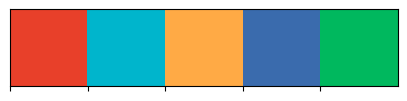

In [3]:
f1_palette = [
    '#E8402A', 
    '#00B5CC',  
    '#FFAA45',  
    '#3A6BAD',  
    '#00B85E',  
]

sns.palplot(sns.color_palette(f1_palette))
plt.show()

In [4]:
sns.set_theme(
    style='white',      
    palette=f1_palette,   
    font='monospace',     
    font_scale=1.2         
)

In [5]:
plt.rcParams['figure.figsize'] = (12, 6) 
plt.rcParams['axes.titlesize'] = 14      
plt.rcParams['axes.labelsize'] = 12      
plt.rcParams['figure.facecolor'] = 'white' 
plt.rcParams['axes.facecolor'] = '#F5F5F0'  
plt.rcParams['figure.facecolor'] = '#F5F5F0'

## 1. The Big Picture

In [6]:
# How has Formula 1 grown over the decades?

query = """ 
WITH decade_stats AS (
        SELECT 
        (year / 10) * 10 AS decade,
        COUNT(DISTINCT ra.raceId) AS total_races,
        COUNT(DISTINCT ra.circuitId) AS unique_circuits,
        COUNT(DISTINCT re.driverId) AS unique_drivers,
        COUNT(DISTINCT re.constructorId) AS unique_constructors
        FROM races ra
        JOIN results re ON ra.raceId = re.raceId
        GROUP BY (year / 10) * 10
)
        SELECT
        decade,
        total_races,
        unique_circuits,
        unique_drivers,
        unique_constructors,
        COALESCE( total_races - LAG(total_races) OVER (ORDER BY decade), 0) AS races_growth,
        COALESCE(unique_circuits - LAG(unique_circuits) OVER (ORDER BY decade), 0) AS circuits_growth,
        COALESCE(unique_drivers - LAG(unique_drivers) OVER (ORDER BY decade), 0) AS drivers_growth,
        COALESCE(unique_constructors - LAG(unique_constructors) OVER (ORDER BY decade), 0) AS constructors_growth
        FROM decade_stats
        ORDER BY decade
        """

df = pd.read_sql(query, conn)
df

,decade,total_races,unique_circuits,unique_drivers,unique_constructors,races_growth,circuits_growth,drivers_growth,constructors_growth
0,1950,84,19,332,69,0,0,0,0
1,1960,100,25,219,71,16,6,-113,2
2,1970,144,28,173,55,44,3,-46,-16
3,1980,156,31,115,31,12,3,-58,-24
4,1990,162,26,105,33,6,-5,-10,2
5,2000,174,24,71,23,12,-2,-34,-10
6,2010,198,27,66,19,24,3,-5,-4
7,2020,107,30,36,14,-91,3,-30,-5


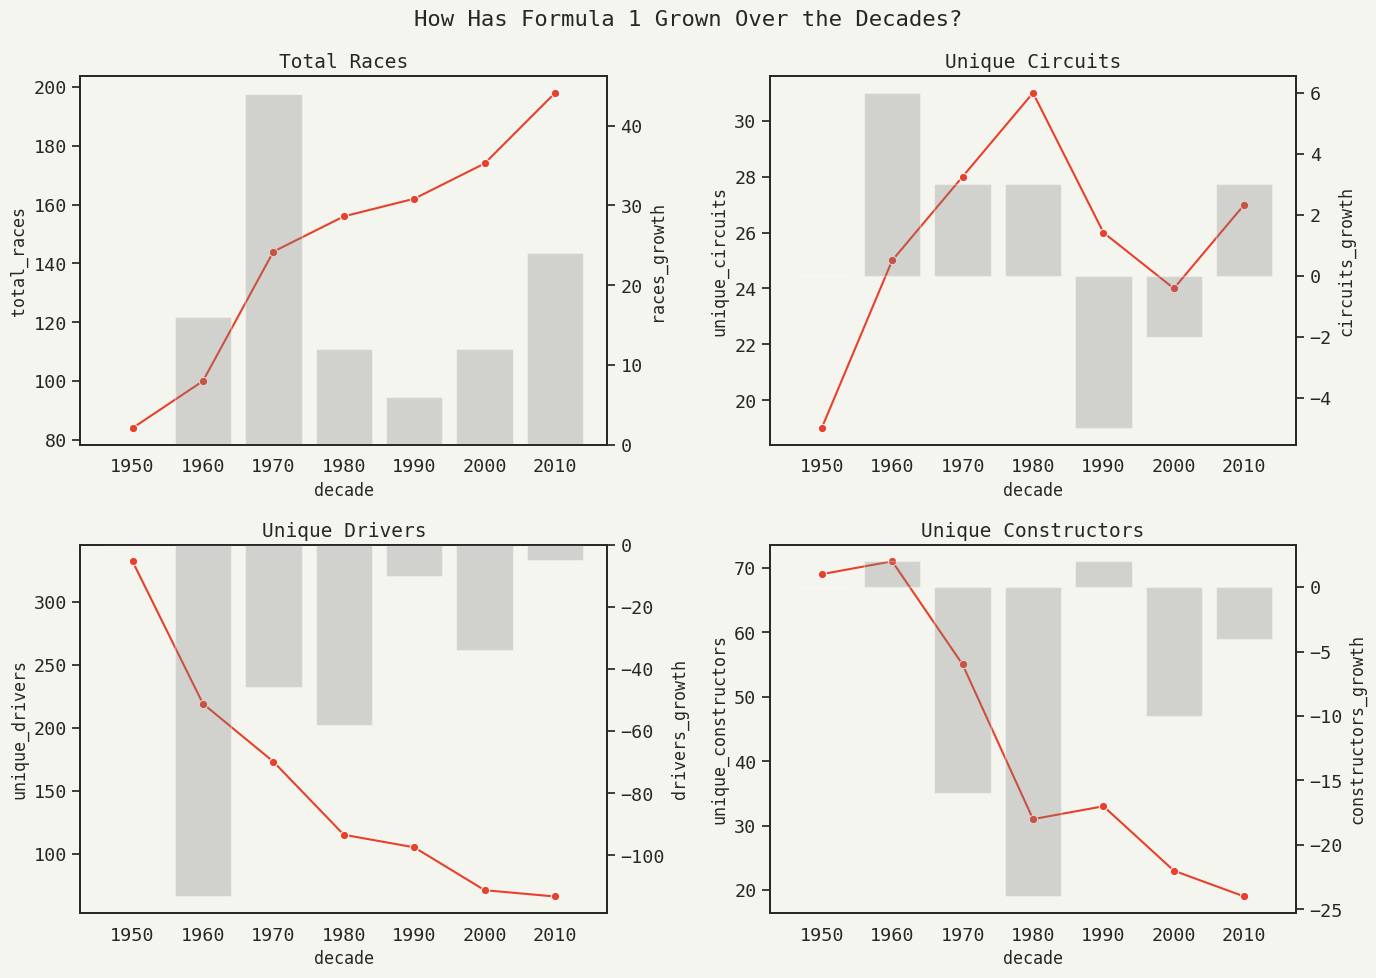

In [7]:
df['decade'] = df['decade'].astype(str)
df = df[df['decade'] != '2020']
# Note: The 2020s decade is excluded from this analysis as it is incomplete (2020–2024 only).
# Including it would underrepresent the decade compared to full 10-year periods.
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# races
ax1_twin = ax1.twinx()
sns.barplot(data=df, x='decade', y='races_growth', ax=ax1_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='total_races', ax=ax1, marker='o')
ax1.set_title('Total Races')

# unique circuits
ax2_twin = ax2.twinx()
sns.barplot(data=df, x='decade', y='circuits_growth', ax=ax2_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='unique_circuits', ax=ax2, marker='o')
ax2.set_title('Unique Circuits')  

# unique drivers
ax3_twin = ax3.twinx()
sns.barplot(data=df, x='decade', y='drivers_growth', ax=ax3_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='unique_drivers', ax=ax3, marker='o')
ax3.set_title('Unique Drivers')

# unique constructors
ax4_twin = ax4.twinx()
sns.barplot(data=df, x='decade', y='constructors_growth', ax=ax4_twin, alpha=0.3, color='gray')
sns.lineplot(data=df, x='decade', y='unique_constructors', ax=ax4, marker='o')
ax4.set_title('Unique Constructors')

plt.suptitle('How Has Formula 1 Grown Over the Decades?', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# In which years the cars were the fastest? 
# Note: some years do not have data regarding speed

query = """
WITH yearly_avg_speed AS(
    SELECT
    ra.year,
    AVG(CAST(re.fastestLapSpeed AS FLOAT)) AS avg_speed
    FROM races ra
    INNER JOIN results re ON re.raceId = ra.raceId
    WHERE re.fastestLapSpeed IS NOT NULL
    AND re.fastestLapSpeed != '\\N'
    AND CAST(re.fastestLapSpeed AS FLOAT) > 0
    GROUP BY ra.year
),
ntile_ranking AS(
    SELECT
    year,
    avg_speed,
    NTILE(4) OVER(ORDER BY avg_speed DESC) AS quartile
    FROM yearly_avg_speed
)
    SELECT
    year,
    ROUND(avg_speed, 2) AS avg_speed,
    quartile,
    CASE quartile
        WHEN 1 THEN 'fastest'
        WHEN 2 THEN 'above average'
        WHEN 3 THEN 'below average'
        WHEN 4 THEN 'slowest'
    END AS speed_category
    FROM ntile_ranking
    ORDER BY year
"""

df = pd.read_sql(query, conn)
df

,year,avg_speed,quartile,speed_category
0,2004,211.74,1,fastest
1,2005,210.24,1,fastest
2,2006,205.18,2,above average
3,2007,203.08,3,below average
4,2008,201.82,3,below average
5,2009,202.21,3,below average
6,2010,197.66,3,below average
7,2011,195.74,4,slowest
8,2012,196.49,4,slowest
9,2013,198.28,3,below average


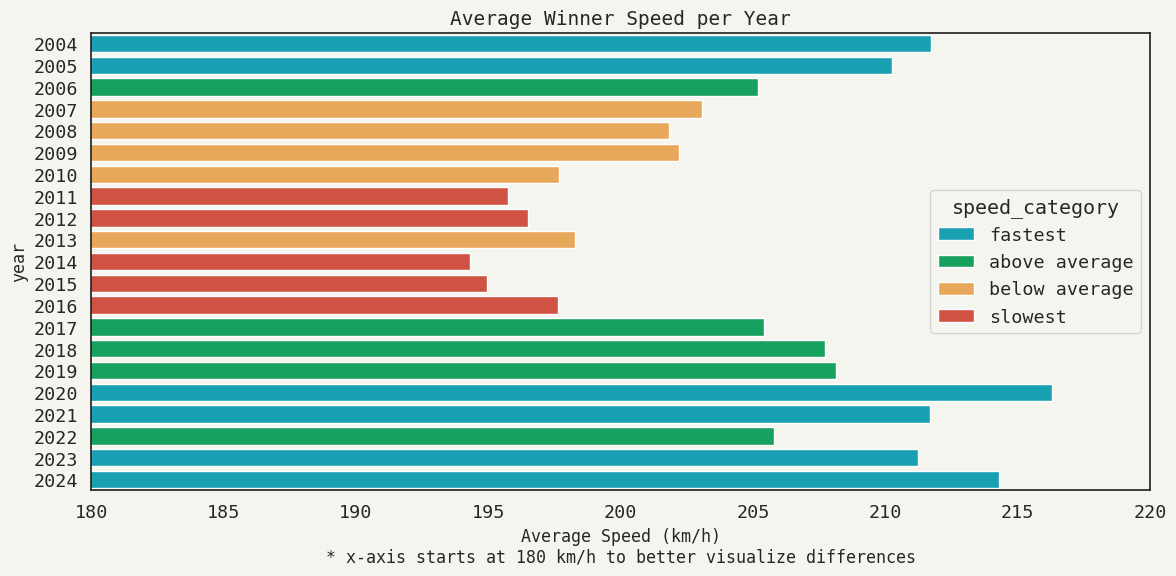

In [9]:
fig, ax = plt.subplots()
sns.barplot(data=df,  x='avg_speed', y='year',  orient='h', hue='speed_category',
            ax=ax,
            palette= {'fastest': '#00B5CC', 
                     'above average': '#00B85E',
                     'below average': '#FFAA45', 
                     'slowest': '#E8402A'})
ax.set_title('Average Winner Speed per Year')
ax.set_xlabel('Average Speed (km/h)\n* x-axis starts at 180 km/h to better visualize differences')
ax.set_ylabel('year')
ax.set_xlim(180, 220) 
plt.tight_layout()
plt.show()

In [10]:
# Which decades had the most races in Formula 1 history?

query = """ 
        SELECT 
        (year / 10) * 10 AS decade,
        RANK() OVER(ORDER BY COUNT(DISTINCT ra.raceId) DESC) as busiest_decade_rank,
        COUNT(DISTINCT ra.raceId) AS total_races
        FROM races ra
        GROUP BY (year / 10) * 10
        ORDER BY decade
        """

pd.read_sql(query, conn)

,decade,busiest_decade_rank,total_races
0,1950,8,84
1,1960,7,100
2,1970,5,144
3,1980,4,156
4,1990,3,162
5,2000,2,174
6,2010,1,198
7,2020,6,107


In [11]:
df['decade'] = df['decade'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='decade', y='total_races', ax=ax)
ax.set_title('Which Decades Had the Most Races in F1 History?')
ax.set_xlabel('Decade')
ax.set_ylabel('Total Races')
ax.text(6.65, 110, 'incomplete\ndata', fontsize=9)
# Note: The 2020s decade is incomplete (2020–2024 only).

plt.tight_layout()
plt.show()

KeyError: 'decade'

In [ ]:
# Quick summary statistics
query = """
    SELECT
        COUNT(DISTINCT raceId) AS total_races,
        COUNT(DISTINCT circuitId) AS total_circuits,
        MIN(year) AS first_season,
        MAX(year) AS last_season
    FROM races
"""

pd.read_sql(query, conn)

## 2. Constructor Dynasties

In [ ]:
#How many race entries have the most popular constructors made in F1 history?

query = """ 
with constructor_stats as(
        SELECT 
        c.name,
        count(*) as total_entries
        FROM constructors c
        INNER JOIN results re on re.constructorId=c.constructorId
        GROUP BY c.constructorId
)
        SELECT 
        RANK() OVER(ORDER BY total_entries DESC) as entry_rank,
        name,
        total_entries
        FROM constructor_stats
        LIMIT 10
        """

df = pd.read_sql(query, conn)
df

In [ ]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='name', x='total_entries', ax=ax)
ax.bar_label(ax.containers[0], padding=5)
ax.set_title('Top 10 Constructors by Total Race Entries')
ax.set_xlabel('Total Entries')
ax.set_ylabel('')
ax.set_xticks(np.arange(0, 3000, 250))
plt.tight_layout()
plt.show()

In [ ]:
# Which constructors won the most races?

query = """ 
WITH constructor_wins AS (
        SELECT 
        c.constructorId,
        c.name,
        COUNT(*) AS total_wins
        FROM constructors c
        INNER JOIN results re ON re.constructorId = c.constructorId
        INNER JOIN races ra ON re.raceId = ra.raceId
        WHERE re.position = 1
        GROUP BY c.constructorId
),
ranked AS (
        SELECT 
        RANK() OVER(ORDER BY total_wins DESC) AS win_rank,
        name,
        total_wins
        FROM constructor_wins
)
        SELECT *
        FROM ranked
        WHERE win_rank <= 10
        ORDER BY win_rank
"""

df = pd.read_sql(query, conn)
df

In [ ]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='name', x='total_wins', ax=ax)
ax.bar_label(ax.containers[0], padding=5)
ax.set_title('Top 10 Constructors by Total Wins')
ax.set_xlabel('Total Wins')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
# What is the distribution of race entries and wins per constructor per season?

query = """ 
        SELECT
        ra.year,
        c.name,
        COUNT(*) AS total_entries,
        SUM(CASE WHEN re.position = 1 THEN 1 ELSE 0 END) AS total_wins
        FROM results re
        JOIN constructors c ON c.constructorId = re.constructorId
        JOIN races ra ON ra.raceId = re.raceId
        GROUP BY re.constructorId, ra.year
"""


df = pd.read_sql(query, conn)
df

In [ ]:
sns.jointplot(data=df, x='total_entries',y='total_wins',kind='hist')

In [ ]:
# Which constructors dominated (in terms of total_wins) each decade of Formula 1?

query = """ 
WITH constructor_wins AS (
        SELECT 
        (ra.year / 10) * 10 AS decade,
        c.name,
        COUNT(*) AS total_wins
        FROM constructors c
        INNER JOIN results re ON re.constructorId = c.constructorId
        INNER JOIN races ra ON re.raceId = ra.raceId
        WHERE re.position = 1
        GROUP BY c.constructorId, decade
),
ranked AS (
        SELECT 
        decade,
        RANK() OVER(PARTITION BY decade ORDER BY total_wins DESC) AS win_rank,
        name,
        total_wins
        FROM constructor_wins
)
        SELECT *
        FROM ranked
        WHERE win_rank <= 3
        ORDER BY decade, win_rank
"""

df = pd.read_sql(query, conn)
df

In [ ]:
decades = df['decade'].unique()

fig, axes = plt.subplots(2, 4, figsize=(16,6))
axes = axes.flatten()
ticks = np.arange(0,120,20)

for i, decade in enumerate(sorted(decades)):
    decade_df = df[df['decade'] == decade]
    sns.barplot(data=decade_df, x='name', y='total_wins', ax=axes[i])
    axes[i].set_title(f'{decade}s')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Wins')
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].set_yticks(ticks)

plt.suptitle('Top 3 Constructors per Decade', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Greatest Drivers

In [ ]:
# Who are the all-time top 10 drivers by points, wins and podiums? 

query = """ 
WITH drivers_result_info AS(
       SELECT 
       d.driverId,
       d.forename,
       d.surname,
       re.points,
       CASE re.position
              WHEN 1 THEN 1
              ELSE 0
       END AS win,
       CASE 
              WHEN re.position BETWEEN 1 AND 3 THEN 1
              ELSE 0
       END AS podium
       FROM drivers d 
       INNER JOIN results re ON d.driverId = re.driverId
)
       SELECT
       RANK() OVER(ORDER BY SUM(points) DESC) AS rank,
       forename || ' ' || surname AS best_driver,
       SUM(points) AS total_points,
       SUM(win) AS total_wins,
       SUM(podium) AS total_podiums
       FROM drivers_result_info
       GROUP BY driverId
       ORDER BY rank
       LIMIT 10
"""

df = pd.read_sql(query, conn)
df

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=df, y='best_driver', x='total_points', ax=ax1)
ax1.set_title('Total Points')
ax1.set_ylabel('')

sns.barplot(data=df, y='best_driver', x='total_wins', ax=ax2)
ax2.set_title('Total Wins')
ax2.set_ylabel('')

sns.barplot(data=df, y='best_driver', x='total_podiums', ax=ax3)
ax3.set_title('Total Podiums')
ax3.set_ylabel('')

plt.suptitle('Top 10 Drivers All-Time', fontsize=16)
plt.tight_layout()
plt.show()

> **Note on points systems:** F1 has changed its points system multiple times throughout history. 
> The most significant change came in 2010, when the points awarded for a win increased from 10 to 25. 
> This means that drivers who competed primarily before 2010 — such as Michael Schumacher, who won 91 races between 1991 and 2006 — 
> appear to have fewer points than modern drivers despite having outstanding race records. 
> Total points should therefore not be used as the sole measure of a driver's greatness across different eras.

In [ ]:
# How did the top 5 drivers accumulate points throughout their careers?

query = """ 
WITH top_5_drivers AS(
        SELECT 
        d.driverId,
        d.forename,
        d.surname,
        RANK() OVER(ORDER BY SUM(re.points) DESC) AS rank,
        SUM(re.points) as total_points
        FROM drivers d 
        INNER JOIN results re ON d.driverId = re.driverId
        GROUP BY d.driverID
        ORDER BY total_points DESC
        LIMIT 5
), points_and_dates AS(
        SELECT
        t.forename,
        t.surname,
        t.rank,
        year,
        SUM(SUM(re.points)) OVER(PARTITION BY t.driverId ORDER BY year ASC) AS accumulated_points
        FROM top_5_drivers t 
        INNER JOIN results re ON t.driverId = re.driverId
        INNER JOIN races ra ON ra.raceId = re.raceId
        GROUP BY t.driverId, year
)
        SELECT
        forename || ' ' || surname AS driver,
        year,
        accumulated_points
        FROM points_and_dates
        ORDER BY rank, year
        
"""

df = pd.read_sql(query, conn)
df

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x='year', y='accumulated_points', hue='driver', ax=ax)
ax.set_title('Accumulated Points Throughout Career — Top 5 Drivers')
ax.set_xlabel('Year')
ax.set_ylabel('Accumulated Points')
ax.axvline(x=2010, color='gray', linestyle='--', alpha=0.5)
ax.text(2010.2, 100, 'New points system', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

> Note: In 2010, F1 introduced a new points system  
> This explains the steeper accumulation curves after 2010 for all drivers.

In [ ]:
# Which nationalities have the most points and who were their most succesful drivers?

query = """ 
WITH best_nationalities AS(
    SELECT 
    d.nationality,
    SUM(re.points) as nationality_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY nationality
    ORDER BY nationality_points DESC
    LIMIT 10
), drivers_total_points AS(
    SELECT 
    d.driverId,
    d.forename,
    d.surname,
    d.nationality,
    SUM(points) AS driver_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY d.driverId
)
    SELECT
    b.nationality,
    b.nationality_points,
    d.forename || ' ' || d.surname as best_driver,
    d.driver_points as best_driver_total_points
    FROM best_nationalities b
    INNER JOIN drivers_total_points d ON b.nationality=d.nationality
    AND (d.driver_points,d.nationality) IN 
    (     
        SELECT
        MAX(driver_points),
        nationality
        FROM drivers_total_points
        GROUP BY nationality
    )
    ORDER BY nationality_points DESC
        """


df = pd.read_sql(query, conn)
df

In [ ]:
df_melted = df.melt(id_vars=['nationality', 'best_driver'],
                    value_vars=['nationality_points', 'best_driver_total_points'],
                    var_name='metric',
                    value_name='value')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_melted, y='nationality', x='value', hue='metric', ax=ax)
ax.set_title('Top 10 Nationalities by Points vs Best Driver')
ax.set_xlabel('Points')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Which drivers scored above average points for their nationality?

query = """
WITH drivers_total_points AS(
    SELECT
    d.driverId,
    d.forename,
    d.surname,
    d.nationality,
    SUM(re.points) AS driver_points
    FROM drivers d
    INNER JOIN results re ON re.driverId = d.driverId
    GROUP BY d.driverId
)
    SELECT
    forename || ' ' || surname AS driver_name,
    nationality,
    driver_points
    FROM drivers_total_points d
    WHERE driver_points > (
        SELECT AVG(driver_points)
        FROM drivers_total_points d2
        WHERE d2.nationality = d.nationality
    )
    ORDER BY nationality, driver_points DESC
"""

pd.read_sql(query, conn)

## 4. Circuits

In [ ]:
# Which circuits are the most and the least dangerous? (R= Retired)
# We ignore circuits with less than a two hundred entries where DNF can be unstable

query = """ 
WITH circuit_retired_stats AS(
    SELECT 
    c.circuitId,
    c.circuitRef,
    c.name,
    COUNT(*) FILTER(WHERE re.positionText='R') AS retired,
    COUNT(*) AS all_entries
    FROM circuits c
    INNER JOIN races ra ON ra.circuitId = c.circuitId
    INNER JOIN results re ON re.raceId = ra.raceId
    GROUP BY c.circuitId
    HAVING COUNT(*) >= 200
)
    SELECT * FROM (  
        SELECT
        circuitRef,
        name,
        'most dangerous' as category,
        ROUND(retired * 100.0 / all_entries, 2) AS dnf_rate,
        retired,
        all_entries
        FROM circuit_retired_stats
        ORDER BY dnf_rate DESC
        LIMIT 10 )
    UNION ALL
        SELECT * FROM(
        SELECT
        circuitRef,
        name,
        'least dangerous' as category,
        ROUND(retired * 100.0 / all_entries, 2) AS dnf_rate,
        retired,
        all_entries
        FROM circuit_retired_stats
        ORDER BY dnf_rate ASC
        LIMIT 10 )
    ORDER BY dnf_rate DESC
"""

df = pd.read_sql(query, conn)
df

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df, y='name', x='dnf_rate', hue='category', ax=ax, palette=f1_palette[:2])
ax.set_title('Most and Least Dangerous Circuits by DNF Rate')
ax.set_xlabel('DNF Rate (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Which circuits produce the most and the least overtakes on average?
# We ignore circuits with less than two hundred entries where results can be unstable

query = """ 
WITH circuit_overtake_stats AS(
    SELECT 
    c.circuitId,
    c.circuitRef,
    c.name,
    ROUND(AVG(ABS(re.grid - re.positionOrder)), 2) AS avg_position_change,
    COUNT(*) AS all_entries
    FROM circuits c
    INNER JOIN races ra ON ra.circuitId = c.circuitId
    INNER JOIN results re ON re.raceId = ra.raceId
    GROUP BY c.circuitId
    HAVING COUNT(*) >= 200
)
    SELECT * FROM (  
        SELECT
        circuitRef,
        name,
        'most overtakes' AS category,
        avg_position_change,
        all_entries
        FROM circuit_overtake_stats
        ORDER BY avg_position_change DESC
        LIMIT 10 )
    UNION ALL
        SELECT * FROM(
        SELECT
        circuitRef,
        name,
        'least overtakes' AS category,
        avg_position_change,
        all_entries
        FROM circuit_overtake_stats
        ORDER BY avg_position_change ASC
        LIMIT 10 )
    ORDER BY category DESC, avg_position_change DESC
"""

df = pd.read_sql(query, conn)
df

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df, y='name', x='avg_position_change', hue='category', 
            ax=ax, palette=['#E8402A', '#00B5CC'])
ax.set_title('Most and Least Overtaking Circuits')
ax.set_xlabel('Average Position Change')
ax.set_ylabel('')
plt.tight_layout()
plt.show()